In [21]:
import pandas as pd
import numpy as np
import glob
import os
import random
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from gtda.time_series import SlidingWindow
from sklearn.pipeline import Pipeline
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy, Amplitude, NumberOfPoints
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, precision_recall_curve, auc
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

### Загрузка данных (выполнять в случае внесения изменений)

In [3]:
path = './data/raw/data_Q1_2024/' 
all_files = sorted(glob.glob(os.path.join(path, "*.csv")))

In [12]:
failed_serials = set()
all_unique_serials = set()

In [13]:
i = 1
for file in all_files:
    print(f"Читаю {i} файл...")
    df_day = pd.read_csv(file, usecols=['serial_number', 'failure'])
    all_unique_serials.update(df_day['serial_number'].tolist())
    failed_ids = df_day[df_day['failure'] == 1]['serial_number'].tolist()
    failed_serials.update(failed_ids)
    i += 1
    
print(f"Найдено сбойных дисков: {len(list(failed_serials))}")

Читаю 1 файл...
Читаю 2 файл...
Читаю 3 файл...
Читаю 4 файл...
Читаю 5 файл...
Читаю 6 файл...
Читаю 7 файл...
Читаю 8 файл...
Читаю 9 файл...
Читаю 10 файл...
Читаю 11 файл...
Читаю 12 файл...
Читаю 13 файл...
Читаю 14 файл...
Читаю 15 файл...
Читаю 16 файл...
Читаю 17 файл...
Читаю 18 файл...
Читаю 19 файл...
Читаю 20 файл...
Читаю 21 файл...
Читаю 22 файл...
Читаю 23 файл...
Читаю 24 файл...
Читаю 25 файл...
Читаю 26 файл...
Читаю 27 файл...
Читаю 28 файл...
Читаю 29 файл...
Читаю 30 файл...
Читаю 31 файл...
Читаю 32 файл...
Читаю 33 файл...
Читаю 34 файл...
Читаю 35 файл...
Читаю 36 файл...
Читаю 37 файл...
Читаю 38 файл...
Читаю 39 файл...
Читаю 40 файл...
Читаю 41 файл...
Читаю 42 файл...
Читаю 43 файл...
Читаю 44 файл...
Читаю 45 файл...
Читаю 46 файл...
Читаю 47 файл...
Читаю 48 файл...
Читаю 49 файл...
Читаю 50 файл...
Читаю 51 файл...
Читаю 52 файл...
Читаю 53 файл...
Читаю 54 файл...
Читаю 55 файл...
Читаю 56 файл...
Читаю 57 файл...
Читаю 58 файл...
Читаю 59 файл...
Читаю 

In [14]:
healthy_serials_pool = list(all_unique_serials - failed_serials)
random.seed(42)
healthy_serials_sample = random.sample(healthy_serials_pool, 1000)
target_serials = list(failed_serials) + healthy_serials_sample
print(f"Итого дисков для анализа: {len(target_serials)} (Сбойных: {len(failed_serials)}, Здоровых: 1000)")

Итого дисков для анализа: 1978 (Сбойных: 978, Здоровых: 1000)


In [19]:
smart_cols = ['smart_5_raw', 'smart_187_raw', 'smart_188_raw', 'smart_197_raw', 'smart_198_raw']
# Можно добавить smart_189_raw и smart_12_raw
cols_to_load = ['date', 'serial_number', 'failure'] + smart_cols

full_data = []
i = 1
for file in all_files:
    print(f"Читаю {i} файл...")
    df_day = pd.read_csv(file, usecols=lambda x: x in cols_to_load)
    filtered = df_day[df_day['serial_number'].isin(target_serials)]
    full_data.append(filtered)
    i += 1

df = pd.concat(full_data, ignore_index=True)

Читаю 1 файл...
Читаю 2 файл...
Читаю 3 файл...
Читаю 4 файл...
Читаю 5 файл...
Читаю 6 файл...
Читаю 7 файл...
Читаю 8 файл...
Читаю 9 файл...
Читаю 10 файл...
Читаю 11 файл...
Читаю 12 файл...
Читаю 13 файл...
Читаю 14 файл...
Читаю 15 файл...
Читаю 16 файл...
Читаю 17 файл...
Читаю 18 файл...
Читаю 19 файл...
Читаю 20 файл...
Читаю 21 файл...
Читаю 22 файл...
Читаю 23 файл...
Читаю 24 файл...
Читаю 25 файл...
Читаю 26 файл...
Читаю 27 файл...
Читаю 28 файл...
Читаю 29 файл...
Читаю 30 файл...
Читаю 31 файл...
Читаю 32 файл...
Читаю 33 файл...
Читаю 34 файл...
Читаю 35 файл...
Читаю 36 файл...
Читаю 37 файл...
Читаю 38 файл...
Читаю 39 файл...
Читаю 40 файл...
Читаю 41 файл...
Читаю 42 файл...
Читаю 43 файл...
Читаю 44 файл...
Читаю 45 файл...
Читаю 46 файл...
Читаю 47 файл...
Читаю 48 файл...
Читаю 49 файл...
Читаю 50 файл...
Читаю 51 файл...
Читаю 52 файл...
Читаю 53 файл...
Читаю 54 файл...
Читаю 55 файл...
Читаю 56 файл...
Читаю 57 файл...
Читаю 58 файл...
Читаю 59 файл...
Читаю 

### Далее работаем с сохраненными данными

In [3]:
def save_df(df, name='raw_df.parquet'):
    df.to_parquet(name, index=False)

def load_df(name='raw_df.parquet'):
    df = pd.read_parquet(name)
    return df

In [4]:
df = load_df()

In [5]:
df

,date,serial_number,failure,smart_5_raw,smart_187_raw,smart_188_raw,smart_197_raw,smart_198_raw
0,2024-01-01,Z4D07KKK,0,0.0,0.0,0.0,0.0,0.0
1,2024-01-01,Z4D054DM,0,0.0,0.0,0.0,0.0,0.0
2,2024-01-01,Z4D0CB0M,0,0.0,0.0,0.0,0.0,0.0
3,2024-01-01,Z4D04EMR,0,0.0,0.0,0.0,0.0,0.0
4,2024-01-01,Z4D090XX,0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
126780,2024-03-31,ZL2LGJGV,0,0.0,0.0,0.0,0.0,0.0
126781,2024-03-31,ZL2L8WDW,0,0.0,0.0,0.0,0.0,0.0
126782,2024-03-31,ZL2LF6DE,0,0.0,0.0,0.0,0.0,0.0
126783,2024-03-31,92F0A00MFVKG,0,0.0,NaN,NaN,0.0,0.0


### Предобработка сырых данных

In [6]:
smart_cols = ['smart_5_raw', 'smart_187_raw', 'smart_188_raw', 'smart_197_raw', 'smart_198_raw'] 

df[smart_cols] = df[smart_cols].fillna(0)

df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(by=['serial_number', 'date'])

scaler = MinMaxScaler()
df[smart_cols] = scaler.fit_transform(df[smart_cols])

In [7]:
df

,date,serial_number,failure,smart_5_raw,smart_187_raw,smart_188_raw,smart_197_raw,smart_198_raw
789,2024-01-01,1040A035F97G,0,0.000000,0.000000,0.0,0.000000,0.000000
2658,2024-01-02,1040A035F97G,0,0.000000,0.000000,0.0,0.000000,0.000000
4521,2024-01-03,1040A035F97G,0,0.000000,0.000000,0.0,0.000000,0.000000
6370,2024-01-04,1040A035F97G,0,0.000000,0.000000,0.0,0.000000,0.000000
8213,2024-01-05,1040A035F97G,0,0.000000,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...
34447,2024-01-20,ZTN0AMY1,0,0.118078,0.002640,0.0,0.002840,0.002840
36106,2024-01-21,ZTN0AMY1,0,0.124679,0.002701,0.0,0.002978,0.002978
37759,2024-01-22,ZTN0AMY1,0,0.124924,0.002747,0.0,0.002961,0.002961
39404,2024-01-23,ZTN0AMY1,0,0.124924,0.002747,0.0,0.002961,0.002961


### Разделение на Tran/Test

In [8]:
unique_serials = df['serial_number'].unique()

train_serials, test_serials = train_test_split(unique_serials, test_size=0.2, random_state=42)

df_train = df[df['serial_number'].isin(train_serials)]
df_test = df[df['serial_number'].isin(test_serials)]

print(f"Дисков в обучении: {len(train_serials)}, в тесте: {len(test_serials)}")

Дисков в обучении: 1582, в тесте: 396


In [9]:
df_train

,date,serial_number,failure,smart_5_raw,smart_187_raw,smart_188_raw,smart_197_raw,smart_198_raw
789,2024-01-01,1040A035F97G,0,0.000000,0.000000,0.0,0.000000,0.000000
2658,2024-01-02,1040A035F97G,0,0.000000,0.000000,0.0,0.000000,0.000000
4521,2024-01-03,1040A035F97G,0,0.000000,0.000000,0.0,0.000000,0.000000
6370,2024-01-04,1040A035F97G,0,0.000000,0.000000,0.0,0.000000,0.000000
8213,2024-01-05,1040A035F97G,0,0.000000,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...
34447,2024-01-20,ZTN0AMY1,0,0.118078,0.002640,0.0,0.002840,0.002840
36106,2024-01-21,ZTN0AMY1,0,0.124679,0.002701,0.0,0.002978,0.002978
37759,2024-01-22,ZTN0AMY1,0,0.124924,0.002747,0.0,0.002961,0.002961
39404,2024-01-23,ZTN0AMY1,0,0.124924,0.002747,0.0,0.002961,0.002961


In [10]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df[df['serial_number'] == '1040A035F97G'])

,date,serial_number,failure,smart_5_raw,smart_187_raw,smart_188_raw,smart_197_raw,smart_198_raw
789,2024-01-01,1040A035F97G,0,0.0,0.0,0.0,0.0,0.0
2658,2024-01-02,1040A035F97G,0,0.0,0.0,0.0,0.0,0.0
4521,2024-01-03,1040A035F97G,0,0.0,0.0,0.0,0.0,0.0
6370,2024-01-04,1040A035F97G,0,0.0,0.0,0.0,0.0,0.0
8213,2024-01-05,1040A035F97G,0,0.0,0.0,0.0,0.0,0.0
10052,2024-01-06,1040A035F97G,0,0.0,0.0,0.0,0.0,0.0
11883,2024-01-07,1040A035F97G,0,0.0,0.0,0.0,0.0,0.0
13698,2024-01-08,1040A035F97G,0,0.0,0.0,0.0,0.0,0.0
15508,2024-01-09,1040A035F97G,0,0.0,0.0,0.0,0.0,0.0
17305,2024-01-10,1040A035F97G,0,0.0,0.0,0.0,0.0,0.0


In [11]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df[df['serial_number'] == 'ZTN0AMY1'])

,date,serial_number,failure,smart_5_raw,smart_187_raw,smart_188_raw,smart_197_raw,smart_198_raw
731,2024-01-01,ZTN0AMY1,0,0.099988,0.001160,0.0,0.002338,0.002338
2600,2024-01-02,ZTN0AMY1,0,0.100966,0.001160,0.0,0.002338,0.002338
4464,2024-01-03,ZTN0AMY1,0,0.101088,0.001160,0.0,0.002338,0.002338
6314,2024-01-04,ZTN0AMY1,0,0.101455,0.001160,0.0,0.002355,0.002355
8158,2024-01-05,ZTN0AMY1,0,0.102921,0.001160,0.0,0.002372,0.002372
9997,2024-01-06,ZTN0AMY1,0,0.104266,0.001160,0.0,0.002372,0.002372
11828,2024-01-07,ZTN0AMY1,0,0.104633,0.001175,0.0,0.002424,0.002424
13643,2024-01-08,ZTN0AMY1,0,0.105488,0.001175,0.0,0.002493,0.002493
15452,2024-01-09,ZTN0AMY1,0,0.105488,0.001175,0.0,0.002493,0.002493
17250,2024-01-10,ZTN0AMY1,0,0.105488,0.001175,0.0,0.002493,0.002493


### Формирование облаков точек

In [13]:
def prepare_tda_data(df, window_size, stride):
    X_list = []
    y_list = []
    
    for serial, group in df.groupby('serial_number'):
        if len(group) < window_size:
            continue 
            
        values = group[smart_cols].values
        
        sw = SlidingWindow(size=window_size, stride=stride)
        windows = sw.fit_transform(values)
        X_list.append(windows)
        
        label = 1 if group['failure'].any() else 0
        y_list.extend([label] * len(windows))
        
    return np.concatenate(X_list), np.array(y_list)

In [14]:
window_size = 10
stride = 1

X_train, y_train = prepare_tda_data(df_train, window_size, stride)
X_test, y_test = prepare_tda_data(df_test, window_size, stride)

print(f"Форма X_train: {X_train.shape}")
print(f"Форма y_train: {y_train.shape}")
print(f"Форма X_test: {X_test.shape}")
print(f"Форма y_test: {y_test.shape}")

Форма X_train: (88166, 10, 5)
Форма y_train: (88166,)
Форма X_test: (21367, 10, 5)
Форма y_test: (21367,)


### Создаём топологические признаки

In [15]:
homology_dimensions = [0, 1]

persistence = VietorisRipsPersistence(
    metric="euclidean", 
    homology_dimensions=homology_dimensions, 
    n_jobs=-1
)

entropy = PersistenceEntropy(n_jobs=-1)

### Пайплайн

In [16]:
clf = SVC(kernel='rbf', class_weight='balanced', probability=True)

In [17]:
pipeline = Pipeline([
    ('tda', persistence),
    ('entropy', entropy),
    ('scaler', StandardScaler()),
    ('svc', clf)
])

In [23]:
pipeline.fit(X_train, y_train)

# Проверяем на тестовом 
y_pred = pipeline.predict(X_test)
y_score = pipeline.predict_proba(X_test)[:, 1]

KeyboardInterrupt: 

In [32]:
loaded_pipeline = joblib.load('tda_svm_model_v1.joblib')

In [28]:
y_score_train = pipeline.predict_proba(X_train)[:, 1]

In [29]:
y_score_train.shape

(88166,)

### Анализ результатов

              precision    recall  f1-score   support

           0       0.82      0.99      0.90     15531
           1       0.93      0.43      0.59      5836

    accuracy                           0.84     21367
   macro avg       0.87      0.71      0.74     21367
weighted avg       0.85      0.84      0.81     21367



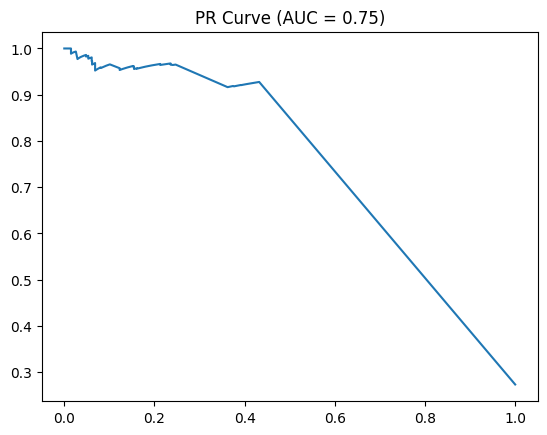

In [19]:
print(classification_report(y_test, y_pred))

precision, recall, _ = precision_recall_curve(y_test, y_score)
plt.plot(recall, precision)
plt.title(f'PR Curve (AUC = {auc(recall, precision):.2f})')
plt.show()

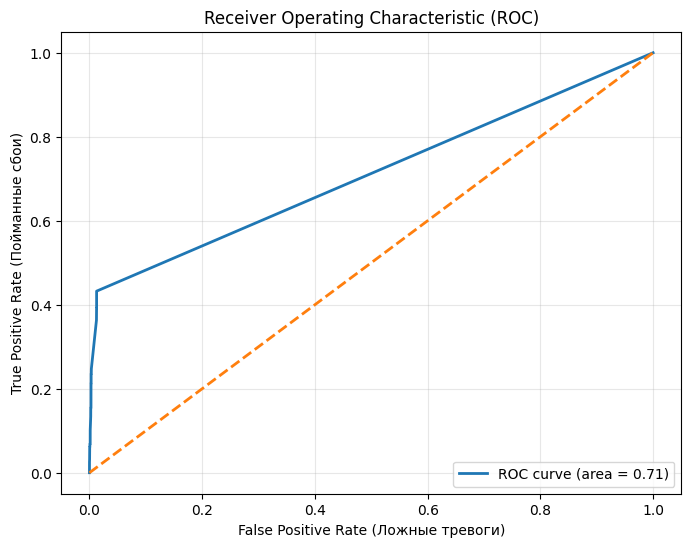

ROC AUC Score: 0.7103


In [20]:
roc_auc = roc_auc_score(y_test, y_score)

fpr, tpr, _ = roc_curve(y_test, y_score)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Ложные тревоги)')
plt.ylabel('True Positive Rate (Пойманные сбои)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

In [22]:
model_filename = 'tda_svm_model_v1.joblib'
joblib.dump(pipeline, model_filename)

['tda_svm_model_v1.joblib']

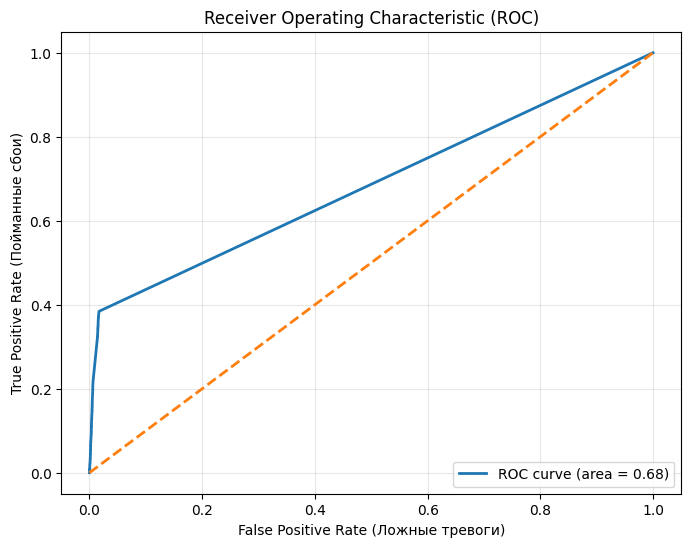

ROC AUC Score: 0.6841


In [30]:
roc_auc = roc_auc_score(y_train, y_score_train)

fpr, tpr, _ = roc_curve(y_train, y_score_train)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Ложные тревоги)')
plt.ylabel('True Positive Rate (Пойманные сбои)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")